<a href="https://colab.research.google.com/github/shreyoshi2304/Ecology-Practical/blob/main/Eco_Evo_Community03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter number of iterations: 100000

Best Run: 12 samples taken
Mode of Sample Counts: 94 (most frequent sample count)

Extracted Samples:

Sample 1:
DCB
CDB
GCB

Sample 2:
CBD
AFA
BDA

Sample 3:
IAE
BAP
JIA

Sample 4:
ADC
DAA
HAC

Sample 5:
DDB
KOB
FAA

Sample 6:
EBA
HSC
AAE

Sample 7:
AEF
CQI
HCA

Sample 8:
GGD
FRB
FAB

Sample 9:
CAB
AGD
BBC

Sample 10:
AKJ
FBM
CND

Sample 11:
ACB
ADC
TCC

Sample 12:
DAC
FCF
GLE

Letter Frequency in Best Sample Set:
A: 24
B: 16
C: 18
D: 13
E: 5
F: 8
G: 5
H: 3
I: 3
J: 2
K: 2
L: 1
M: 1
N: 1
O: 1
P: 1
Q: 1
R: 1
S: 1
T: 1


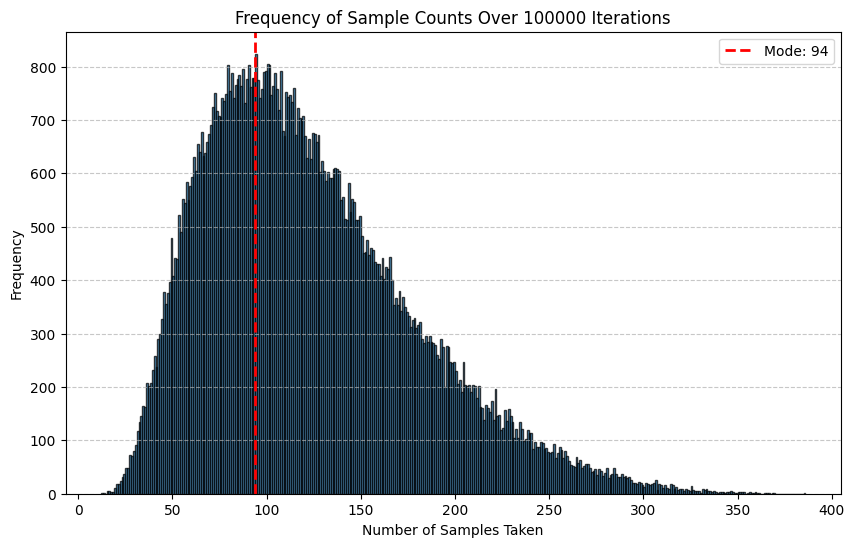

In [ ]:
import random
import matplotlib.pyplot as plt
from collections import Counter

# Sample manually entered 60x60 matrix (each row is a string of 60 characters)
matrix = [
   "EAAFBDCDABCDACBAKJFBFAACAEAHMADFHLBGANGEAAHCACBBGDCAJBIOCIBC",
"BBBJFFHBGBAIADCFBMAAABBAGDJBCRABABEKDACADACDFAFAAADCAABAAHBD",
"ACJCEJBCBAGMTCCCNDDORJBFCMBDCGAFFFBBEABBAGCFABFFNKOCCBAJBRJC",
"ABCDDADAAHDEIAEIFDBBBEAEKACEAADACAACFHHABAGABAEACEHEBDABBGBA",
"CECDABBMFEACCAAEHBALBAJEGIBACDHBFABAAAFDCBBDEACFAAIAACADCAIC",
"CCBICADAGGFDBPBAKBEBCEBCBBDMAGAEADDACNAHMCKHAECBEFACAACHBABC",
"CDACFCAPALGBACAJAACDEHBABBEIBCHACDACAGACBCBALABDBGSDABCCCDKA",
"BDCAPAAEEEANAABEJKBBBBDGBABAGABACFCFCMDCADCECDNBDGAECEGAAEAI",
"BAEBFAACACCADBBABEHCGBEJBDEAGABELGLEGBFACGEAFCBEBECECCCCGBBE",
"HBGCBHADAAJAGGDACBAABHAFGJBFABGQACCBMAFEFAABAQBCKEABBBCGAFDD",
"DDJAABBDABCAFRBIDBCABCAFDABAKABJBCBCBGCGABCFOADEDDAEGFAAGCGA",
"BEAAFCJCBDAAFABBABGAAIAABBAHCAGBDAFJBFBCADADADDDAAGFJAGBAAEA",
"DAACBPBJHDBBGGBADHLHBAABAFBIAEBACKBAGAKADCBBJAAAMGDDAAAHACFD",
"BAABAAAAAAFDIOCGBCDDACAADHCBAPBDCABBCBADAADECECDBADBAELACDBA",
"CBFKDAGBBEBGHADKIAFFABHCBFEJIACDAECCDGCHACBECEDAABLAACGCCABC",
"DCBBFAEHAAGAOAAABABGADAGCAIABEBCMFBJBBBIBADBADBFGCIEHAEABAIA",
"BBDCECBBAGABAEBHBAACEBDBFEADAIAACDABBELBADAHDCGKABDDDCDDBFDA",
"EEACADACIAEJDAFEFEEBFAEBBECAABDCKDBDACADDCBBCEAFBABEIJFCADFA",
 "GEDCFFDCBEFBAFBFFADFNEECAABBLIADBAKBCGGCAAABDCHBFBEAICBFCBBF",
 "BBFBAACHIDBDACEAABADTICANCACDAGHBBDHADAILAECBFBBIBEGBAFBIAAF",
 "BFBCCAIGCLAECCBJAABCBABIBGABEFBBCCABDCACDHBCCECABFACHBBCABBD",
 "MFDAFCACEADAFAGCBEACBEGBDAAABABCBBCCAAABCICADCAEAFAHACHBCLAA",
 "IBDDAAACJAKGENBACBBFHCQBBBFLIDPBCFBDBCCDICAHCAAFADAAACECACCB",
 "EEDDGJDAKACDCJHAAANBHAGKBEABHPBDADSGCAANGBABCABBBCCAGCBACGEC",
"DAADCDACCBHJFBGAAABGCKBDDEABDGCBHCADIEAEEAAABMABEAIDCBEEBDAA",
"FABCBCJCCDBBCABCAFACBECACBADABMCECFLAACMAEEEHCABCBCCBCCBCAHB",
"GBABCBDKAAFBCDACAFBAAGDBADABACNBDABDHBACFCCDPIAJAFAGAAECBBGB",
"BBECEHBDDBEABDDEAAAEBABBCECDCBAFGBLCAJDAACAAACBDABCFAACLALBB",
"EBCCBIJDDABCCACAGAFDDAHAABBCDBECABBPIABBDBDHBAFABCAEBCEGDBAD",
"HENLMBLKBCCCDEECBCEHBIABNJFGCBEEBAIEBGEDAJJAEBDAABDDIDAFGFEG",
"FEEFCHAADDDBAGAAGFBKBEAAGACEBDBAGIEDIABCABEGADABEGBIAADAABAD",
"EABAAEAAFKOBCAGIDFCHFCJBABACIALACEACAFFAGDJDHGHCEHBBCGAAACBH",
"ABDBFADFBFAABACEBGBFHBBCDHDDGBAJCCBEBBBBBCDGJADBHBEECACBLBGA",
"CKCBCABHJDEADAAFDJEBAHCAAEDCJDBEEACHCKCADEEBEDJFGBBBAACBCECD",
"DEEAACHAAABHAFHAEDHSCABDDBAAAACAIABGBFBBFFEBECFAAACKOFABACBA",
"DDDEBBAABAAAFAAAACAAECIFFBCFAABEKEAAEABHDBAAEAIAJAADAAEGGCCG",
"CACAEFCFBACCAGGEBAFABAAABGDAMBEADEBBBFAAAAHABJBCBBKADECGFDAC",
"CDBCQIAACEEADBBEBABGDDEBECIDBCACPBGAACCBHBAACCFAFDOKBDDBEEHB",
"IDBHCADBBAFABDCABBBAOECAACCBDHAHLBCBBAACCCABBAEAEICAEHAFAABH",
"ABHAECGCBCABBDIMBEAADGBDEBDBAOAHADCKBCQABLIBHDADABADBHMACFAA",
"CEADHFBAECADFADBGEBAAACIEAHAAAICNFICADDAEADCBFDCCBCLCCCDBBBD",
"DIHEDJDEDADDCABCDAADFCDACBDCDBAGAEFAACAAFCBDBBEBECDDBBBCCFEA",
"DBCBOAMBIAFACJLLDEAFFACBFBBABFDADFBDCFCAEDBDGFIBMACBAGDAACKD",
"CADACAFACABBDFCAALACANCDEDFDBAAFOBHDACBAAHCBAKGHAHBSKAAAACGB",
"BHODBBEBFBCABECFJDEAAKBDBAFCGJCBBDNFDBDABAADEDBCBBACNAKCBCAB",
"ACCHABADCBBMDBABGFCFBAEDDBFCCGCCAEAIACALDACCHBABFAAEAAADDAEF",
"BDTAGBBCFBCEFBLLABCEAAGCAEAEHFCDKEGCFHAMABADECAGARCBFMHGAABB",
"BEEBCDIBDFDAAFGBDAELBGAABCAEHGDBAAAAEAFJABKCABBEAAABCACKFCGE",
"DCDCDDBEBAGBJJGHAABFBGAABDBHDABJAFBBEBAIFEIEBBABJHBBFBADBQKC",
"BBKBCCBIICEDAABEGDAEMHAABLAACIBAFECEFAFABCCIAIDGDBEEFBABAAAA",
"HLABABEEAAADIADAGADCAEFIAEAEADBABABCCDGCDEBFHDBACCIDDHCFECIE",
"HADEEBECDBIJBCDBAHFDCGCBEBAAJAKBAGGEBACKCCLAFDDDBJEAGDABAFNA",
"DBACCCBAGFFABBCAAACROAEAFDAABJBAIABCGDAABHFDQBAEAABADECCDCBN",
"KBBDAGACEAFADACDBMADBAECABABAEFHDCIBBIBFGABEFCAGBDBBBEEAAABA",
"DGACAAEFACAAAEACABCCDBECBGAEDDAAAAHCAAIBFCIAEADEAFACKBCACAAC",
"AFBAECFDJGBCDADDDACEBABADCDAACDABBFCCBABEAEKESCEBBCDABEHDBCC",
"CDAEEDABFEDFCAACGADGCLEFACFFABGPABABHBAAAKCDAHGFBEAABMAEDHBC",
"AADBDJBCHCCIBADCAABABCEBBFACRDBDDGADHFCACLAABDACGKCBGOCAIJCA",
"ACEABBDBAADEEAQAABFDBABFBHDDDBBBCCABCIBBAAABCABAJEIBAABICDFA",
"CCCADFNACBBDBMEGJAAGAAAPTQIGAEKECCAJCMCAAEDHAABAHHCABBJBKDCE"
]

# Ensure matrix is properly formatted
assert len(matrix) == 60 and all(len(row) == 60 for row in matrix), "Matrix must be 60x60."

# Define the set of required letters (A to T)
required_letters = set("ABCDEFGHIJKLMNOPQRST")

# Function to extract 3x3 non-overlapping samples
def extract_samples(matrix):
    covered_letters = set()
    samples = []
    sample_count = 0

    # Generate a list of all possible 3x3 starting positions (non-overlapping)
    positions = [(r, c) for r in range(0, 60, 3) for c in range(0, 60, 3)]
    random.shuffle(positions)  # Shuffle to randomize sample order

    for r, c in positions:
        # Extract the 3x3 sample
        sample = [matrix[i][c:c+3] for i in range(r, r+3)]
        samples.append(sample)
        sample_count += 1

        # Update covered letters
        for row in sample:
            covered_letters.update(row)

        # If all required letters are covered, stop
        if required_letters.issubset(covered_letters):
            break

    return sample_count, samples, covered_letters

# User-specified number of iterations
num_iterations = int(input("Enter number of iterations: "))

# Variables to track the best result
best_sample_count = float('inf')
best_samples = []
best_letter_count = {}
sample_counts = []  # Store all sample counts for histogram

# Run the process multiple times
for _ in range(num_iterations):
    sample_count, samples, covered_letters = extract_samples(matrix)
    sample_counts.append(sample_count)  # Store for histogram

    # Update best result if a lower sample count is found
    if sample_count < best_sample_count:
        best_sample_count = sample_count
        best_samples = samples
        best_letter_count = Counter("".join("".join(row) for row in samples))  # Count letters in the best set

# Calculate mode of sample counts
mode_sample_count = Counter(sample_counts).most_common(1)[0][0]  # Most frequent sample count

# Output the best result
print(f"\nBest Run: {best_sample_count} samples taken")
print(f"Mode of Sample Counts: {mode_sample_count} (most frequent sample count)")
print("\nExtracted Samples:")
for idx, sample in enumerate(best_samples, 1):
    print(f"\nSample {idx}:")
    for row in sample:
        print(row)

# Print letter count
print("\nLetter Frequency in Best Sample Set:")
for letter, count in sorted(best_letter_count.items()):
    print(f"{letter}: {count}")

# Plot histogram of sample counts
plt.figure(figsize=(10, 6))
plt.hist(sample_counts, bins=range(min(sample_counts), max(sample_counts) + 1), edgecolor='black', alpha=0.75)
plt.axvline(mode_sample_count, color='red', linestyle='dashed', linewidth=2, label=f"Mode: {mode_sample_count}")
plt.xlabel("Number of Samples Taken")
plt.ylabel("Frequency")
plt.title(f"Frequency of Sample Counts Over {num_iterations} Iterations")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

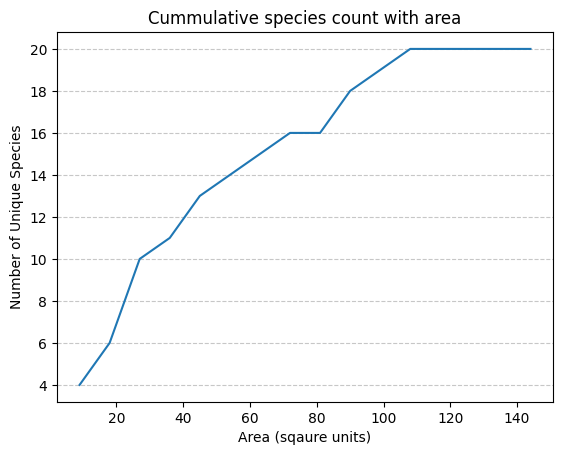

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = [9,18,27,36,45,54,63,72,81,90,99,108,117,126,135,144]
y= [4,6,10,11,13,14,15,16,16,18,19,20,20,20,20,20]
plt.plot(x,y)
plt.xlabel("Area (sqaure units)")
plt.ylabel("Number of Unique Species")
plt.title("Cummulative species count with area")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
import scipy.stats as stats
import random

# Expected frequencies based on the given data
expected_frequencies = np.array([
    902, 677, 508, 381, 286, 214, 161, 121, 90, 68,
    51, 38, 29, 21, 16, 12, 9, 7, 5, 4
])

# Normalize expected frequencies to sum to 3600
expected_frequencies = (expected_frequencies / np.sum(expected_frequencies)) * 3600

def list_to_matrix(matrix_list):
    """Convert a list of strings into a NumPy character matrix."""
    return np.array([list(row) for row in matrix_list])

def extract_random_3x3(matrix):
    """Extract a random 3x3 non-overlapping sample from the given matrix."""
    rows, cols = matrix.shape
    if rows < 3 or cols < 3:
        raise ValueError("Matrix must be at least 3x3 in size.")

    row_idx = random.randint(0, rows - 3)
    col_idx = random.randint(0, cols - 3)

    return matrix[row_idx:row_idx+3, col_idx:col_idx+3]

def compute_chi_square(observed, expected):
    """Compute the Chi-Square statistic for given observed and expected frequencies."""
    expected = expected.copy()
    expected[expected == 0] = 1  # Avoid division by zero
    chi_square_stat = np.sum((observed - expected) ** 2 / expected)
    return chi_square_stat

# Example input: Replace with the actual character-based matrix
matrix_list = [
   "EAAFBDCDABCDACBAKJFBFAACAEAHMADFHLBGANGEAAHCACBBGDCAJBIOCIBC",
"BBBJFFHBGBAIADCFBMAAABBAGDJBCRABABEKDACADACDFAFAAADCAABAAHBD",
"ACJCEJBCBAGMTCCCNDDORJBFCMBDCGAFFFBBEABBAGCFABFFNKOCCBAJBRJC",
"ABCDDADAAHDEIAEIFDBBBEAEKACEAADACAACFHHABAGABAEACEHEBDABBGBA",
"CECDABBMFEACCAAEHBALBAJEGIBACDHBFABAAAFDCBBDEACFAAIAACADCAIC",
"CCBICADAGGFDBPBAKBEBCEBCBBDMAGAEADDACNAHMCKHAECBEFACAACHBABC",
"CDACFCAPALGBACAJAACDEHBABBEIBCHACDACAGACBCBALABDBGSDABCCCDKA",
"BDCAPAAEEEANAABEJKBBBBDGBABAGABACFCFCMDCADCECDNBDGAECEGAAEAI",
"BAEBFAACACCADBBABEHCGBEJBDEAGABELGLEGBFACGEAFCBEBECECCCCGBBE",
"HBGCBHADAAJAGGDACBAABHAFGJBFABGQACCBMAFEFAABAQBCKEABBBCGAFDD",
"DDJAABBDABCAFRBIDBCABCAFDABAKABJBCBCBGCGABCFOADEDDAEGFAAGCGA",
"BEAAFCJCBDAAFABBABGAAIAABBAHCAGBDAFJBFBCADADADDDAAGFJAGBAAEA",
"DAACBPBJHDBBGGBADHLHBAABAFBIAEBACKBAGAKADCBBJAAAMGDDAAAHACFD",
"BAABAAAAAAFDIOCGBCDDACAADHCBAPBDCABBCBADAADECECDBADBAELACDBA",
"CBFKDAGBBEBGHADKIAFFABHCBFEJIACDAECCDGCHACBECEDAABLAACGCCABC",
"DCBBFAEHAAGAOAAABABGADAGCAIABEBCMFBJBBBIBADBADBFGCIEHAEABAIA",
"BBDCECBBAGABAEBHBAACEBDBFEADAIAACDABBELBADAHDCGKABDDDCDDBFDA",
"EEACADACIAEJDAFEFEEBFAEBBECAABDCKDBDACADDCBBCEAFBABEIJFCADFA",
 "GEDCFFDCBEFBAFBFFADFNEECAABBLIADBAKBCGGCAAABDCHBFBEAICBFCBBF",
 "BBFBAACHIDBDACEAABADTICANCACDAGHBBDHADAILAECBFBBIBEGBAFBIAAF",
 "BFBCCAIGCLAECCBJAABCBABIBGABEFBBCCABDCACDHBCCECABFACHBBCABBD",
 "MFDAFCACEADAFAGCBEACBEGBDAAABABCBBCCAAABCICADCAEAFAHACHBCLAA",
 "IBDDAAACJAKGENBACBBFHCQBBBFLIDPBCFBDBCCDICAHCAAFADAAACECACCB",
 "EEDDGJDAKACDCJHAAANBHAGKBEABHPBDADSGCAANGBABCABBBCCAGCBACGEC",
"DAADCDACCBHJFBGAAABGCKBDDEABDGCBHCADIEAEEAAABMABEAIDCBEEBDAA",
"FABCBCJCCDBBCABCAFACBECACBADABMCECFLAACMAEEEHCABCBCCBCCBCAHB",
"GBABCBDKAAFBCDACAFBAAGDBADABACNBDABDHBACFCCDPIAJAFAGAAECBBGB",
"BBECEHBDDBEABDDEAAAEBABBCECDCBAFGBLCAJDAACAAACBDABCFAACLALBB",
"EBCCBIJDDABCCACAGAFDDAHAABBCDBECABBPIABBDBDHBAFABCAEBCEGDBAD",
"HENLMBLKBCCCDEECBCEHBIABNJFGCBEEBAIEBGEDAJJAEBDAABDDIDAFGFEG",
"FEEFCHAADDDBAGAAGFBKBEAAGACEBDBAGIEDIABCABEGADABEGBIAADAABAD",
"EABAAEAAFKOBCAGIDFCHFCJBABACIALACEACAFFAGDJDHGHCEHBBCGAAACBH",
"ABDBFADFBFAABACEBGBFHBBCDHDDGBAJCCBEBBBBBCDGJADBHBEECACBLBGA",
"CKCBCABHJDEADAAFDJEBAHCAAEDCJDBEEACHCKCADEEBEDJFGBBBAACBCECD",
"DEEAACHAAABHAFHAEDHSCABDDBAAAACAIABGBFBBFFEBECFAAACKOFABACBA",
"DDDEBBAABAAAFAAAACAAECIFFBCFAABEKEAAEABHDBAAEAIAJAADAAEGGCCG",
"CACAEFCFBACCAGGEBAFABAAABGDAMBEADEBBBFAAAAHABJBCBBKADECGFDAC",
"CDBCQIAACEEADBBEBABGDDEBECIDBCACPBGAACCBHBAACCFAFDOKBDDBEEHB",
"IDBHCADBBAFABDCABBBAOECAACCBDHAHLBCBBAACCCABBAEAEICAEHAFAABH",
"ABHAECGCBCABBDIMBEAADGBDEBDBAOAHADCKBCQABLIBHDADABADBHMACFAA",
"CEADHFBAECADFADBGEBAAACIEAHAAAICNFICADDAEADCBFDCCBCLCCCDBBBD",
"DIHEDJDEDADDCABCDAADFCDACBDCDBAGAEFAACAAFCBDBBEBECDDBBBCCFEA",
"DBCBOAMBIAFACJLLDEAFFACBFBBABFDADFBDCFCAEDBDGFIBMACBAGDAACKD",
"CADACAFACABBDFCAALACANCDEDFDBAAFOBHDACBAAHCBAKGHAHBSKAAAACGB",
"BHODBBEBFBCABECFJDEAAKBDBAFCGJCBBDNFDBDABAADEDBCBBACNAKCBCAB",
"ACCHABADCBBMDBABGFCFBAEDDBFCCGCCAEAIACALDACCHBABFAAEAAADDAEF",
"BDTAGBBCFBCEFBLLABCEAAGCAEAEHFCDKEGCFHAMABADECAGARCBFMHGAABB",
"BEEBCDIBDFDAAFGBDAELBGAABCAEHGDBAAAAEAFJABKCABBEAAABCACKFCGE",
"DCDCDDBEBAGBJJGHAABFBGAABDBHDABJAFBBEBAIFEIEBBABJHBBFBADBQKC",
"BBKBCCBIICEDAABEGDAEMHAABLAACIBAFECEFAFABCCIAIDGDBEEFBABAAAA",
"HLABABEEAAADIADAGADCAEFIAEAEADBABABCCDGCDEBFHDBACCIDDHCFECIE",
"HADEEBECDBIJBCDBAHFDCGCBEBAAJAKBAGGEBACKCCLAFDDDBJEAGDABAFNA",
"DBACCCBAGFFABBCAAACROAEAFDAABJBAIABCGDAABHFDQBAEAABADECCDCBN",
"KBBDAGACEAFADACDBMADBAECABABAEFHDCIBBIBFGABEFCAGBDBBBEEAAABA",
"DGACAAEFACAAAEACABCCDBECBGAEDDAAAAHCAAIBFCIAEADEAFACKBCACAAC",
"AFBAECFDJGBCDADDDACEBABADCDAACDABBFCCBABEAEKESCEBBCDABEHDBCC",
"CDAEEDABFEDFCAACGADGCLEFACFFABGPABABHBAAAKCDAHGFBEAABMAEDHBC",
"AADBDJBCHCCIBADCAABABCEBBFACRDBDDGADHFCACLAABDACGKCBGOCAIJCA",
"ACEABBDBAADEEAQAABFDBABFBHDDDBBBCCABCIBBAAABCABAJEIBAABICDFA",
"CCCADFNACBBDBMEGJAAGAAAPTQIGAEKECCAJCMCAAEDHAABAHHCABBJBKDCE"
]
given_matrix = list_to_matrix(matrix_list)
total_chi_square = float('inf')
sample_count = 0
combined_observed = np.zeros(20)  # Assuming 20 species

while total_chi_square >= 30.144 or sample_count == 0:
    sample_matrix = extract_random_3x3(given_matrix)

    # Count occurrences of each species in the sample
    unique, counts = np.unique(sample_matrix, return_counts=True)
    sample_observed = dict(zip(unique, counts))

    # Map species A-T to indices 0-19
    observed_freq = np.zeros(20)
    for idx, species in enumerate("ABCDEFGHIJKLMNOPQRST"):
        if species in sample_observed:
            observed_freq[idx] = sample_observed[species]

    # Merge with previously observed counts
    combined_observed += observed_freq

    # Scale observed frequency to sum to 3600
    if np.sum(combined_observed) > 0:
        scaled_observed = (combined_observed / np.sum(combined_observed)) * 3600
    else:
        scaled_observed = combined_observed  # Avoid division by zero if all counts are zero

    # Compute Chi-Square statistic
    total_chi_square = compute_chi_square(scaled_observed, expected_frequencies)

    sample_count += 1

print(f"Minimum samples needed: {sample_count}")
print(f"Final Chi-Square Value: {total_chi_square:.4f}")

Minimum samples needed: 115
Final Chi-Square Value: 26.9271


In [ ]:
import numpy as np
import random

# Expected frequencies based on the given data
expected_frequencies = np.array([
    902, 677, 508, 381, 286, 214, 161, 121, 90, 68,
    51, 38, 29, 21, 16, 12, 9, 7, 5, 4
])

# Normalize expected frequencies to sum to 3600
expected_frequencies = (expected_frequencies / np.sum(expected_frequencies)) * 3600

def list_to_matrix(matrix_list):
    """Convert a list of strings into a NumPy character matrix."""
    return np.array([list(row) for row in matrix_list])

def extract_random_3x3(matrix):
    """Extract a random 3x3 non-overlapping sample from the given matrix."""
    rows, cols = matrix.shape
    row_idx = random.randint(0, rows - 3)
    col_idx = random.randint(0, cols - 3)
    return matrix[row_idx:row_idx+3, col_idx:col_idx+3]

def compute_chi_square(observed, expected):
    """Compute the Chi-Square statistic for given observed and expected frequencies."""
    expected = expected.copy()
    expected[expected == 0] = 1  # Avoid division by zero
    return np.sum((observed - expected) ** 2 / expected)

# Example input: Replace with the actual character-based matrix
matrix_list = [
   "EAAFBDCDABCDACBAKJFBFAACAEAHMADFHLBGANGEAAHCACBBGDCAJBIOCIBC",
"BBBJFFHBGBAIADCFBMAAABBAGDJBCRABABEKDACADACDFAFAAADCAABAAHBD",
"ACJCEJBCBAGMTCCCNDDORJBFCMBDCGAFFFBBEABBAGCFABFFNKOCCBAJBRJC",
"ABCDDADAAHDEIAEIFDBBBEAEKACEAADACAACFHHABAGABAEACEHEBDABBGBA",
"CECDABBMFEACCAAEHBALBAJEGIBACDHBFABAAAFDCBBDEACFAAIAACADCAIC",
"CCBICADAGGFDBPBAKBEBCEBCBBDMAGAEADDACNAHMCKHAECBEFACAACHBABC",
"CDACFCAPALGBACAJAACDEHBABBEIBCHACDACAGACBCBALABDBGSDABCCCDKA",
"BDCAPAAEEEANAABEJKBBBBDGBABAGABACFCFCMDCADCECDNBDGAECEGAAEAI",
"BAEBFAACACCADBBABEHCGBEJBDEAGABELGLEGBFACGEAFCBEBECECCCCGBBE",
"HBGCBHADAAJAGGDACBAABHAFGJBFABGQACCBMAFEFAABAQBCKEABBBCGAFDD",
"DDJAABBDABCAFRBIDBCABCAFDABAKABJBCBCBGCGABCFOADEDDAEGFAAGCGA",
"BEAAFCJCBDAAFABBABGAAIAABBAHCAGBDAFJBFBCADADADDDAAGFJAGBAAEA",
"DAACBPBJHDBBGGBADHLHBAABAFBIAEBACKBAGAKADCBBJAAAMGDDAAAHACFD",
"BAABAAAAAAFDIOCGBCDDACAADHCBAPBDCABBCBADAADECECDBADBAELACDBA",
"CBFKDAGBBEBGHADKIAFFABHCBFEJIACDAECCDGCHACBECEDAABLAACGCCABC",
"DCBBFAEHAAGAOAAABABGADAGCAIABEBCMFBJBBBIBADBADBFGCIEHAEABAIA",
"BBDCECBBAGABAEBHBAACEBDBFEADAIAACDABBELBADAHDCGKABDDDCDDBFDA",
"EEACADACIAEJDAFEFEEBFAEBBECAABDCKDBDACADDCBBCEAFBABEIJFCADFA",
 "GEDCFFDCBEFBAFBFFADFNEECAABBLIADBAKBCGGCAAABDCHBFBEAICBFCBBF",
 "BBFBAACHIDBDACEAABADTICANCACDAGHBBDHADAILAECBFBBIBEGBAFBIAAF",
 "BFBCCAIGCLAECCBJAABCBABIBGABEFBBCCABDCACDHBCCECABFACHBBCABBD",
 "MFDAFCACEADAFAGCBEACBEGBDAAABABCBBCCAAABCICADCAEAFAHACHBCLAA",
 "IBDDAAACJAKGENBACBBFHCQBBBFLIDPBCFBDBCCDICAHCAAFADAAACECACCB",
 "EEDDGJDAKACDCJHAAANBHAGKBEABHPBDADSGCAANGBABCABBBCCAGCBACGEC",
"DAADCDACCBHJFBGAAABGCKBDDEABDGCBHCADIEAEEAAABMABEAIDCBEEBDAA",
"FABCBCJCCDBBCABCAFACBECACBADABMCECFLAACMAEEEHCABCBCCBCCBCAHB",
"GBABCBDKAAFBCDACAFBAAGDBADABACNBDABDHBACFCCDPIAJAFAGAAECBBGB",
"BBECEHBDDBEABDDEAAAEBABBCECDCBAFGBLCAJDAACAAACBDABCFAACLALBB",
"EBCCBIJDDABCCACAGAFDDAHAABBCDBECABBPIABBDBDHBAFABCAEBCEGDBAD",
"HENLMBLKBCCCDEECBCEHBIABNJFGCBEEBAIEBGEDAJJAEBDAABDDIDAFGFEG",
"FEEFCHAADDDBAGAAGFBKBEAAGACEBDBAGIEDIABCABEGADABEGBIAADAABAD",
"EABAAEAAFKOBCAGIDFCHFCJBABACIALACEACAFFAGDJDHGHCEHBBCGAAACBH",
"ABDBFADFBFAABACEBGBFHBBCDHDDGBAJCCBEBBBBBCDGJADBHBEECACBLBGA",
"CKCBCABHJDEADAAFDJEBAHCAAEDCJDBEEACHCKCADEEBEDJFGBBBAACBCECD",
"DEEAACHAAABHAFHAEDHSCABDDBAAAACAIABGBFBBFFEBECFAAACKOFABACBA",
"DDDEBBAABAAAFAAAACAAECIFFBCFAABEKEAAEABHDBAAEAIAJAADAAEGGCCG",
"CACAEFCFBACCAGGEBAFABAAABGDAMBEADEBBBFAAAAHABJBCBBKADECGFDAC",
"CDBCQIAACEEADBBEBABGDDEBECIDBCACPBGAACCBHBAACCFAFDOKBDDBEEHB",
"IDBHCADBBAFABDCABBBAOECAACCBDHAHLBCBBAACCCABBAEAEICAEHAFAABH",
"ABHAECGCBCABBDIMBEAADGBDEBDBAOAHADCKBCQABLIBHDADABADBHMACFAA",
"CEADHFBAECADFADBGEBAAACIEAHAAAICNFICADDAEADCBFDCCBCLCCCDBBBD",
"DIHEDJDEDADDCABCDAADFCDACBDCDBAGAEFAACAAFCBDBBEBECDDBBBCCFEA",
"DBCBOAMBIAFACJLLDEAFFACBFBBABFDADFBDCFCAEDBDGFIBMACBAGDAACKD",
"CADACAFACABBDFCAALACANCDEDFDBAAFOBHDACBAAHCBAKGHAHBSKAAAACGB",
"BHODBBEBFBCABECFJDEAAKBDBAFCGJCBBDNFDBDABAADEDBCBBACNAKCBCAB",
"ACCHABADCBBMDBABGFCFBAEDDBFCCGCCAEAIACALDACCHBABFAAEAAADDAEF",
"BDTAGBBCFBCEFBLLABCEAAGCAEAEHFCDKEGCFHAMABADECAGARCBFMHGAABB",
"BEEBCDIBDFDAAFGBDAELBGAABCAEHGDBAAAAEAFJABKCABBEAAABCACKFCGE",
"DCDCDDBEBAGBJJGHAABFBGAABDBHDABJAFBBEBAIFEIEBBABJHBBFBADBQKC",
"BBKBCCBIICEDAABEGDAEMHAABLAACIBAFECEFAFABCCIAIDGDBEEFBABAAAA",
"HLABABEEAAADIADAGADCAEFIAEAEADBABABCCDGCDEBFHDBACCIDDHCFECIE",
"HADEEBECDBIJBCDBAHFDCGCBEBAAJAKBAGGEBACKCCLAFDDDBJEAGDABAFNA",
"DBACCCBAGFFABBCAAACROAEAFDAABJBAIABCGDAABHFDQBAEAABADECCDCBN",
"KBBDAGACEAFADACDBMADBAECABABAEFHDCIBBIBFGABEFCAGBDBBBEEAAABA",
"DGACAAEFACAAAEACABCCDBECBGAEDDAAAAHCAAIBFCIAEADEAFACKBCACAAC",
"AFBAECFDJGBCDADDDACEBABADCDAACDABBFCCBABEAEKESCEBBCDABEHDBCC",
"CDAEEDABFEDFCAACGADGCLEFACFFABGPABABHBAAAKCDAHGFBEAABMAEDHBC",
"AADBDJBCHCCIBADCAABABCEBBFACRDBDDGADHFCACLAABDACGKCBGOCAIJCA",
"ACEABBDBAADEEAQAABFDBABFBHDDDBBBCCABCIBBAAABCABAJEIBAABICDFA",
"CCCADFNACBBDBMEGJAAGAAAPTQIGAEKECCAJCMCAAEDHAABAHHCABBJBKDCE"
]

given_matrix = list_to_matrix(matrix_list)

# Run the process 10,000 times and find the minimum samples needed
min_samples = float('inf')

for _ in range(100):
    total_chi_square = float('inf')
    sample_count = 0
    combined_observed = np.zeros(20)  # Assuming 20 species (A-T)

    while total_chi_square >= 30.144 or sample_count == 0:
        sample_matrix = extract_random_3x3(given_matrix)

        # Count occurrences of each species in the sample
        unique, counts = np.unique(sample_matrix, return_counts=True)
        sample_observed = dict(zip(unique, counts))

        # Map species A-T to indices 0-19
        observed_freq = np.zeros(20)
        for idx, species in enumerate("ABCDEFGHIJKLMNOPQRST"):
            if species in sample_observed:
                observed_freq[idx] = sample_observed[species]

        # Merge with previously observed counts
        combined_observed += observed_freq

        # Scale observed frequency to sum to 3600
        if np.sum(combined_observed) > 0:
            scaled_observed = (combined_observed / np.sum(combined_observed)) * 3600
        else:
            scaled_observed = combined_observed  # Avoid division by zero if all counts are zero

        # Compute Chi-Square statistic
        total_chi_square = compute_chi_square(scaled_observed, expected_frequencies)

        sample_count += 1

    # Track the minimum samples needed
    min_samples = min(min_samples, sample_count)

print(f"Minimum samples needed across 10,000 iterations: {min_samples}")
print(f"Final Chi-Square Value: {total_chi_square:.4f}")

Minimum samples needed across 10,000 iterations: 89
Final Chi-Square Value: 29.7686
